# Imports

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skfda import FDataGrid
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.smoothing import BasisSmoother

## Set current dir to project root dir

In [2]:
def find_project_root():
    """Walk up from CWD until we find the project root."""
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())

In [3]:
# 1. Read the CSV
eeg_df = pd.read_csv("./ds006018_per_stimuli/sub-001/task-auditoryoddball_Stimulus_S80.csv")

# 2. Reshape to time x epoch matrix for channel CP1
eeg_matrix = eeg_df.pivot(index="time", columns="epoch", values="CP1")
time_points = eeg_matrix.index.to_numpy(dtype=float)
data_matrix = eeg_matrix.to_numpy()

# 3. Create FDataGrid
fd_grid = FDataGrid(
    data_matrix=data_matrix.T,
    grid_points=time_points
)

# 4. B-spline basis (nbasis=20)
time_range = (time_points[0], time_points[-1])
basis = BSplineBasis(domain_range=time_range, n_basis=20)

# 5. Smooth
smoother = BasisSmoother(basis)
eeg_fd = smoother.fit_transform(fd_grid)

print(eeg_fd)
print("done")

Data set:    [[[  7.0374528 ]
  [  6.37663425]
  [  5.76769276]
  ...
  [ -4.6225328 ]
  [ -4.62953602]
  [ -4.63343407]]

 [[  4.841143  ]
  [  3.65425725]
  [  2.59142867]
  ...
  [  5.73008125]
  [  6.6339565 ]
  [  7.63673572]]

 [[  1.75690248]
  [  1.86088381]
  [  1.97145156]
  ...
  [ -5.04174925]
  [ -5.03865492]
  [ -5.05131934]]

 ...

 [[  1.69696871]
  [  0.77561714]
  [ -0.02650151]
  ...
  [-11.7325143 ]
  [-11.33491679]
  [-10.8926041 ]]

 [[ 10.56824369]
  [  9.4287383 ]
  [  8.36174862]
  ...
  [ -2.48888643]
  [ -2.14233158]
  [ -1.82456713]]

 [[ 16.95068864]
  [ 12.40260068]
  [  8.3504588 ]
  ...
  [  0.2567786 ]
  [  0.90061794]
  [  1.60313682]]]
grid_points:    (array([-0.2  , -0.198, -0.196, -0.194, -0.192, -0.19 , -0.188, -0.186,
       -0.184, -0.182, -0.18 , -0.178, -0.176, -0.174, -0.172, -0.17 ,
       -0.168, -0.166, -0.164, -0.162, -0.16 , -0.158, -0.156, -0.154,
       -0.152, -0.15 , -0.148, -0.146, -0.144, -0.142, -0.14 , -0.138,
       -0.136, -0.13

/tmp/ipykernel_3091202/1400169786.py:3: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  amplitudes = eeg_fd.evaluate(time_eval).squeeze()  # (n_epochs, 500)


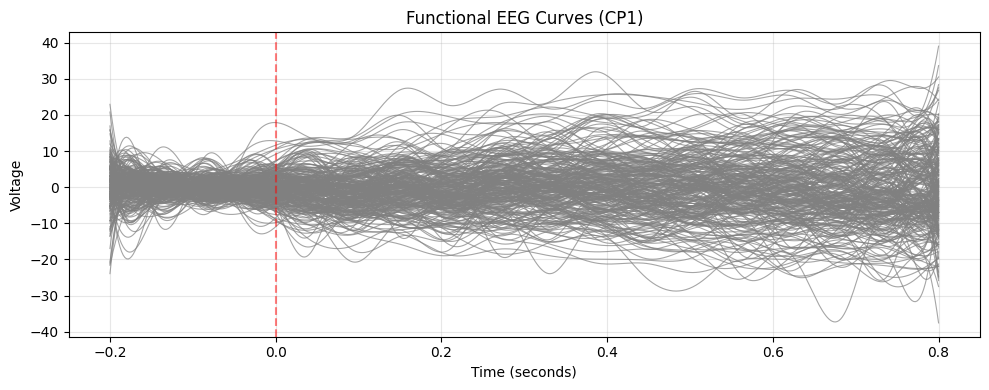

done


In [4]:
# 6. Plot all epochs (spaghetti plot)
time_eval = np.linspace(time_range[0], time_range[1], 500)
amplitudes = eeg_fd.evaluate(time_eval).squeeze()  # (n_epochs, 500)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_eval, amplitudes.T, color="gray", linewidth=0.8, alpha=0.7)
ax.axvline(x=0, linestyle="--", color="red", alpha=0.5)
ax.set_title("Functional EEG Curves (CP1)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Voltage")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("done")

In [5]:
# Load from pkl
with open("./ds006018_functional/sub-001/task-auditoryoddball_Stimulus_S1.pkl", "rb") as f:
    eeg_fd = pickle.load(f)

/tmp/ipykernel_3091202/2681390548.py:4: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  amplitudes = eeg_fd.evaluate(time_eval).squeeze()


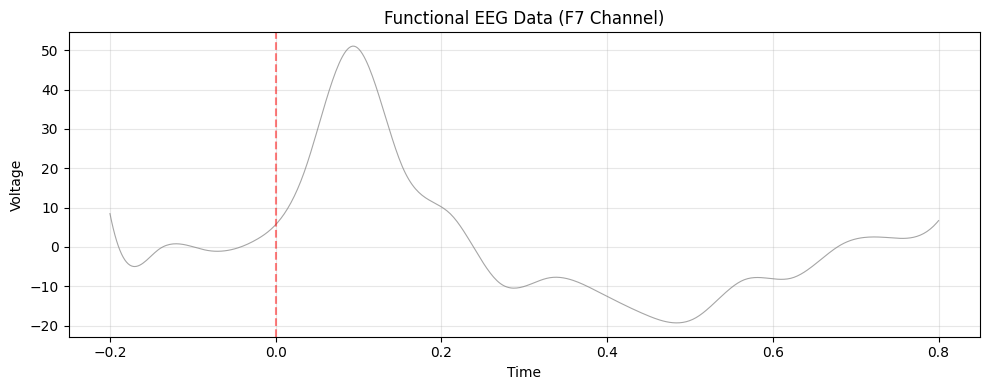

done


In [6]:
# Plot all epochs (spaghetti plot)
time_range = eeg_fd.domain_range[0]
time_eval = np.linspace(time_range[0], time_range[1], 500)
amplitudes = eeg_fd.evaluate(time_eval).squeeze()

# Handle single-epoch case (S1 has only 1 trial)
if amplitudes.ndim == 1:
    amplitudes = amplitudes[np.newaxis, :]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_eval, amplitudes.T, color="gray", linewidth=0.8, alpha=0.7)
ax.axvline(x=0, linestyle="--", color="red", alpha=0.5)
ax.set_title("Functional EEG Data (F7 Channel)")
ax.set_xlabel("Time")
ax.set_ylabel("Voltage")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("done")

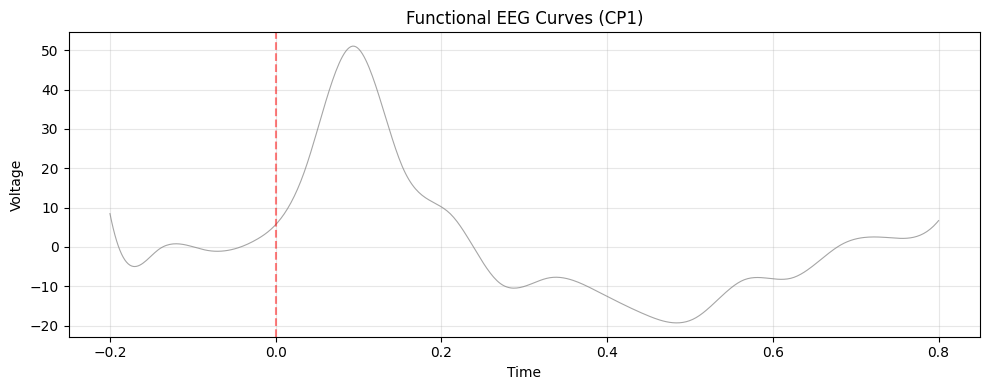

In [7]:
# Plot again with different title
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_eval, amplitudes.T, color="gray", linewidth=0.8, alpha=0.7)
ax.axvline(x=0, linestyle="--", color="red", alpha=0.5)
ax.set_title("Functional EEG Curves (CP1)")
ax.set_xlabel("Time")
ax.set_ylabel("Voltage")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()